# Monte Carlo Control in a Windy GridWorld

## Problem

An agent must learn to navigate in a 5x5 grid from bottom-left corner (0, 0) to the top-right corner (4, 4). At each step, it chooses one of four actions [up, down, left, right], moving one cell in the chosen direction.

## Environment

- **Wind**: at each agent's movement, wind may push the agent in some direction with different magnitudes, depending on the specific implementation.
- **Walls**: the agent cannot exit the grid; when it hits a wall (i.e. its position results outside the grid), it is clipped back into the grid and suffers a penalty.
- **Rewards**: +1 for reaching the goal, -0.1 for hitting a wall, 0 otherwise.
- **Episodes**: an episode ends when the agent reaches the goal, or after 200 steps. The discount factor is $\gamma = 0.9$.

## Approach

We use tabular Monte Carlo methods (both prediction and control, where exploration is ensured through $\epsilon$-soft policies), which learn from complete episodes. The algorithms used are in the following images:
![MC prediction](img/MC%20prediction.png)
![MC control](img/MC%20control.png)

## Code

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time as time
from tqdm import trange
from itertools import product
from typing import NamedTuple
from enum import StrEnum
from matplotlib.patches import Circle
from abc import ABC, abstractmethod

BOARD_SIZE = 5

class GridState(NamedTuple):
    row: int
    col: int

    # it's useful to add GridStates automatically
    def __add__(self, other: object) -> 'GridState':
        if isinstance(other, GridState):
            return GridState(self.row + other.row, self.col + other.col)
        elif isinstance(other, tuple) and len(other) == 2:
            return GridState(self.row + other[0], self.col + other[1])
        raise NotImplementedError

    def is_valid(self, board_size: int = BOARD_SIZE) -> bool:
        """Checks if the state lies within the valid board grid"""
        return 0 <= self.row < board_size and 0 <= self.col < board_size

    def clip(self, board_size: int = BOARD_SIZE) -> 'GridState':
        """Clips the coordinates within [0, board_size - 1]"""
        clipped_row = max(0, min(self.row, board_size - 1))
        clipped_col = max(0, min(self.col, board_size - 1))
        return GridState(row = clipped_row, col = clipped_col)

class Action(StrEnum):
    UP = 'up'
    DOWN = 'down'
    LEFT = 'left'
    RIGHT = 'right'

    @property
    def delta(self) -> GridState:
        """Returns the (row, col) shift for this action"""
        match self:
            case Action.UP:     return GridState(1, 0)
            case Action.DOWN:   return GridState(-1, 0)
            case Action.LEFT:   return GridState(0, -1)
            case Action.RIGHT:  return GridState(0, 1)
    @property
    def idx(self) -> int:
        """Returns the numerical index of the action for Q-table lookup."""
        match self:
            case Action.UP:     return 0
            case Action.DOWN:   return 1
            case Action.LEFT:   return 2
            case Action.RIGHT:  return 3
    @classmethod
    def from_idx(cls, idx: int) -> "Action":
        """Converts an integer index back to its corresponding Action enum."""
        assert(0 <= idx < 4)
        return list(cls)[idx]

We first define a few possible environments.

In [12]:
class GridEnvironment:
    def __init__(self, size = BOARD_SIZE):
        self.state = GridState(0, 0) # start in bottom-left corner
        self.size = size
        self.goal = GridState(size - 1, size - 1)

    def wind(self, action: Action) -> GridState:
        return GridState(0, 0)  # no wind at all

    def move(self, action: Action) -> tuple[GridState, float, bool]:
        self.state += self.wind(action) + action.delta
        hit_wall: bool = not self.state.is_valid()
        self.state = self.state.clip()
        done: bool = self.state == self.goal
        reward: float = int(done) - hit_wall * 0.1
        return self.state, reward, done

    def reset(self) -> GridState:
        self.state = GridState(0, 0)
        return self.state

    def draw(self):
        fig, ax = plt.subplots()
        # Draw grid
        for i in range(self.size + 1):
            ax.plot([0, self.size], [i, i], color='black')
            ax.plot([i, i], [0, self.size], color='black')
        # Add coordinates inside the grid in the top-right corner of each cell
        for i, j in product(range(self.size), repeat = 2):
            ax.text(j + 0.95, i + 0.95, f"({j},{i})", fontsize=8, color='gray', ha='right', va='top')
        # Draw goal (circle)
        ax.add_patch(Circle((self.goal.col + 0.5, self.goal.row + 0.5), 0.3, color = 'red', label = 'Goal'))
        # Draw player (circle)
        ax.add_patch(Circle((self.state.col + 0.5, self.state.row + 0.5), 0.3, color = 'blue', label = 'Player'))
        # Set limits and grid settings
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')
        plt.show()  

# adds a stochastic perpendicular wind disturbance
class SymmetricWindGridEnvironment(GridEnvironment):
    def __init__(self, size = BOARD_SIZE, prob = 0.9):
        super().__init__(size)
        self.prob = prob

    def wind(self, action: Action) -> GridState:
        if np.random.rand() >= self.prob: return GridState(0, 0) # no wind
        if action in (Action.UP, Action.DOWN): # then wind is horizzontal
            return GridState(0, np.random.choice([-1, 1]))
        return GridState(np.random.choice([-1, 1]), 0) # wind is vertical

# adds a stochastic perpendicular wind disturbance that can vary in magnitude
class AsymmetricWindGridEnvironment(GridEnvironment):
    def __init__(self, size = BOARD_SIZE, prob = 0.9):
        super().__init__(size)
        self.prob = prob
    def wind(self, action: Action) -> GridState:
        if np.random.rand() >= self.prob: return GridState(0, 0) # no wind
        if action in (Action.UP, Action.DOWN): # wind is horizzontal
            return GridState(0, np.random.choice([-2, -1, 1]))
        return GridState(np.random.choice([-2, -1, 1]), 0)

Now we define both Value functions and Action-Value functions, that will be stored in a tabular form.

In [13]:
class Value(ABC):
    def __init__(self, size = BOARD_SIZE, gamma = 0.9, alpha = 0.1):
        self.V, self.counts = np.zeros((size, size)), np.zeros((size, size))
        self.gamma, self.alpha, self.size = gamma, alpha, size

    @abstractmethod
    def update(self,
               trajectory: list[GridState],
               rewards: list[float]) -> None:
        pass

    def _running_avg_update(self, G: float, s: GridState) -> None:
        idx = (s.row, s.col)
        self.counts[idx] += 1
        # Running average update: V(s) = V(s) + (G - V(s)) / N(s)
        self.V[idx] += (G - self.V[idx]) / self.counts[idx]

    def draw(self):
        fig, ax = plt.subplots()
        # Create a color map based on the value grid
        cax = ax.imshow(self.V, cmap='coolwarm', origin='lower', extent=(0, self.size, 0, self.size))
        # Add a color bar to indicate value levels
        fig.colorbar(cax)
        # Draw grid lines
        for i in range(self.size + 1):
            ax.plot([0, self.size], [i, i], color='black', lw=0.5)
            ax.plot([i, i], [0, self.size], color='black', lw=0.5)
        # Add coordinates and values inside the grid in the top-right corner of each cell
        for i, j in product(range(self.size), repeat = 2):
            val = self.V[i, j] # i = row, j = col
            ax.text(j + 0.9, i + 0.9, f"({j},{i})", fontsize=8, color='gray', ha='right', va='top')
            # Optionally display the value itself at the center of the cell
            ax.text(j + 0.5, i + 0.5, f"{val:.2f}", fontsize=8, color='black', ha='center', va='center')
        # Set limits and grid settings
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_aspect('equal')
        plt.show()

class ValueEveryVisit(Value):
    def update(self, trajectory: list[GridState], rewards: list[float]) -> None:
        """Updates V using Every-Visit Monte Carlo returns."""
        G = 0
        for s, r in zip(reversed(trajectory), reversed(rewards)):
            G = self.gamma * G + r
            self._running_avg_update(G, s)

class ValueFirstVisit(Value):
    def update(self, trajectory: list[GridState], rewards: list[float]) -> None:
        G, returns = 0, []
        for r in reversed(rewards):
            G = self.gamma * G + r
            returns.append(G)
        returns.reverse() # match trajectory order
        visited: set[GridState] = set()
        for s, g in zip(trajectory, returns):
            if s not in visited:
                visited.add(s)
                self._running_avg_update(g, s)

In [14]:
class ActionValue(ABC):
    def __init__(self, size = BOARD_SIZE, gamma = 0.9, alpha = 0.1):
        self.size, self.gamma, self.alpha = size, gamma, alpha
        self.Q = np.zeros((size, size, len(Action)))
        self.counts = np.zeros((size, size, len(Action)))

    def _running_avg_update(self, G: float, s: GridState, a: Action) -> None:
        idx = (s.row, s.col, a.idx)
        self.counts[idx] += 1
        # Running average update: Q(s, a) = Q(s, a) + (G - Q(s, a)) / N(s, a)
        self.Q[idx] += (G - self.Q[idx]) / self.counts[idx]
    
    @abstractmethod
    def update(
        self, 
        trajectory: list[GridState], 
        actions: list[Action], 
        rewards: list[float]
        ) -> None:
        """Updates the Q table based on episode experience."""
        pass

class ActionValueEveryVisit(ActionValue):
    def update(
            self, 
            trajectory: list[GridState], 
            actions: list[Action], 
            rewards: list[float]
            ) -> None:
        """Updates Q using Every-Visit Monte Carlo returns."""
        G = 0.0
        for s, a, r in zip(reversed(trajectory), reversed(actions), reversed(rewards)):
            G = self.gamma * G + r
            self._running_avg_update(G, s, a)

class ActionValueFirstVisit(ActionValue):
    def update(
            self, 
            trajectory: list[GridState], 
            actions: list[Action], 
            rewards: list[float]
            ) -> None:
        """Updates Q using First-Visit Monte Carlo returns."""
        G, returns = 0, []
        for r in reversed(rewards):
            G = self.gamma * G + r
            returns.append(G)
        returns.reverse()   # match order of trajectory
        visited: set[tuple[GridState, Action]] = set()
        for s, a, g in zip(trajectory, actions, returns):
            if (s, a) not in visited:
                visited.add((s, a))
                self._running_avg_update(g, s, a)

Now we need the policies.

In [15]:
class Policy(ABC):
    def __init__(self, size = BOARD_SIZE):
        self.size = size
    @abstractmethod
    def act(self, s: GridState) -> Action:
        pass

# abstract class for control policies, that need Q
class PolicyControl(Policy):
    def __init__(self, action_value: ActionValue, size = BOARD_SIZE):
        self.size = size
        self.action_value = action_value
    
class EpsilonSoftPolicy(PolicyControl):
    def __init__(self, 
                 action_value: ActionValue,
                 epsilon = 0.1,
                 decay = 1.0,
                 min_epsilon = 0.01,
                 size = BOARD_SIZE):
        super().__init__(action_value, size = size)
        self.epsilon, self.decay, self.min_epsilon = epsilon, decay, min_epsilon
    def act(self, s: GridState) -> Action:
        # Exploration: pick a uniform random action
        if np.random.rand() < self.epsilon:
            return Action.from_idx(np.random.randint(len(Action)))
        # Exploitation: pick the best action according to Q (break ties at random)
        Q_s = self.action_value.Q[s.row, s.col]
        max_q = np.max(Q_s)
        best_action_idxs = np.flatnonzero(Q_s == max_q) # find all indices with max_q
        chosen_idx = int(np.random.choice(best_action_idxs)) # break ties at random
        return Action.from_idx(chosen_idx)
    def decay_epsilon(self) -> None:
        self.epsilon = max(self.min_epsilon, self.epsilon * self.decay)
        

Now that we have all the ingredients, we can start the training loop.

In [16]:
def train_mc_control(
        env: GridEnvironment,
        policy: EpsilonSoftPolicy,
        num_episodes: int = 2000,
        max_steps_per_episode: int = 200
) -> list[float]:
    """Trains an epsilon-soft policy using Monte Carlo control.
    
    Returns:
        returns_history: total reward accumulated per episode.
    """
    returns_history: list[float] = []
    for episode in trange(num_episodes):
        s = env.reset()
        trajectory, actions, rewards = [], [], []
        for _ in range(max_steps_per_episode):
            a = policy.act(s)
            actions.append(a)
            trajectory.append(s)
            s, r, done = env.move(a)
            rewards.append(r)
            if done: break
        policy.action_value.update(trajectory, actions, rewards)
        policy.decay_epsilon()
        returns_history.append(sum(rewards))
    return returns_history

def mc_prediction(
    env: GridEnvironment,
    value: Value,
    policy: Policy,
    num_episodes: int = 2000,
    max_steps_per_episode: int = 200
) -> None:
    """Estimates V for the given policy."""
    for episode in trange(num_episodes):
        s = env.reset()
        trajectory, rewards = [], []
        for _ in range(max_steps_per_episode):
            a = policy.act(s)
            trajectory.append(s)
            s, r, done = env.move(a)
            rewards.append(r)
            if done: break
        value.update(trajectory, rewards)
    

def plot_history(history: list[float]):
    plt.plot(history, alpha = 0.3, label = 'per episode')
    plt.xlabel('episode')
    plt.ylabel('return')
    plt.legend()
    plt.show()

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:23<00:00, 84.85it/s] 


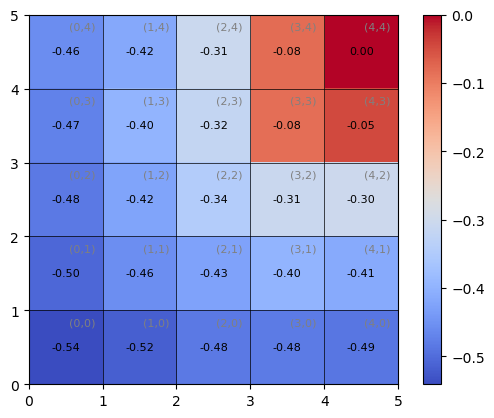

In [17]:
env = AsymmetricWindGridEnvironment()
action_value = ActionValueFirstVisit()
value = ValueFirstVisit()
policy = EpsilonSoftPolicy(action_value = action_value, decay = 0.995)
mc_prediction(env, value, policy)
value.draw()

100%|██████████| 2000/2000 [00:04<00:00, 494.51it/s]


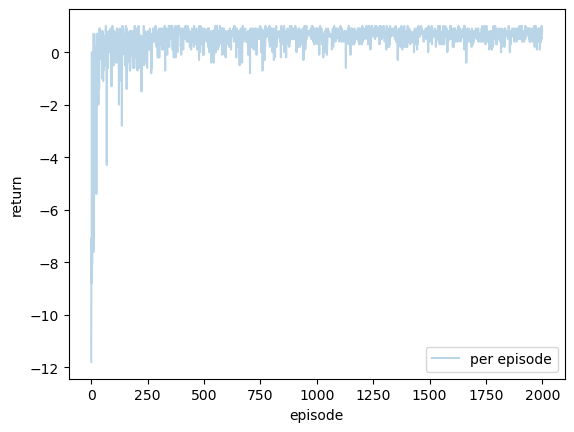

In [18]:
history = train_mc_control(env, policy)
plot_history(history)

100%|██████████| 2000/2000 [00:02<00:00, 732.54it/s]


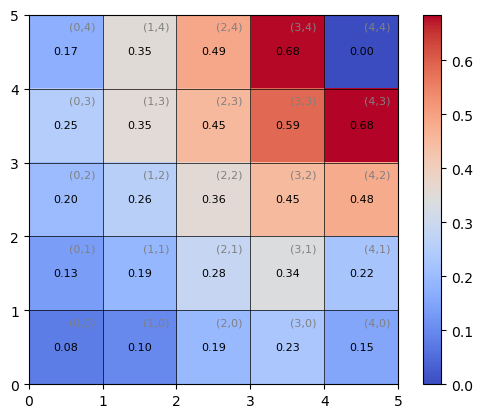

In [19]:
value = ValueFirstVisit()
mc_prediction(env, value, policy)
value.draw()

Let's try with a harder environment.

In [20]:
class HardGridEnvironment(GridEnvironment):
    def __init__(self, size = BOARD_SIZE, prob = 0.9):
        super().__init__(size)
        self.prob = prob
    def wind(self, action: Action) -> GridState:
        if np.random.rand() >= self.prob: return GridState(0, 0) # no wind
        row, col = self.state
        match (row % 2, col % 2):
            case (0, 0): return GridState(0, np.random.choice([-2, -1, 1]))
            case (0, 1): return GridState(np.random.choice([-1, 1, 2]), 0)
            case (1, 0): return GridState(np.random.choice([-2, -1, 1]), 0)
            case _:      return GridState(0, np.random.choice([-1, 1, 2]))

100%|██████████| 2000/2000 [00:11<00:00, 168.14it/s]


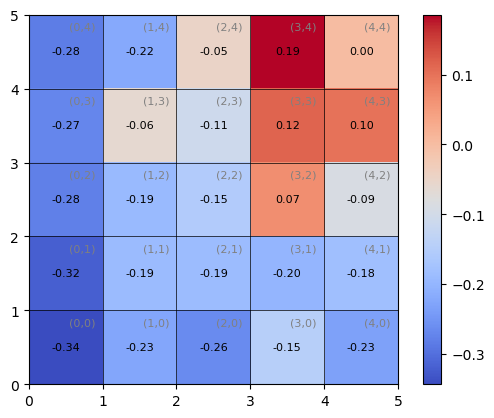

In [21]:
env = HardGridEnvironment()
action_value = ActionValueFirstVisit()
value = ValueFirstVisit()
policy = EpsilonSoftPolicy(action_value = action_value, decay = 0.995)
mc_prediction(env, value, policy)
value.draw()

100%|██████████| 2000/2000 [00:01<00:00, 1017.66it/s]


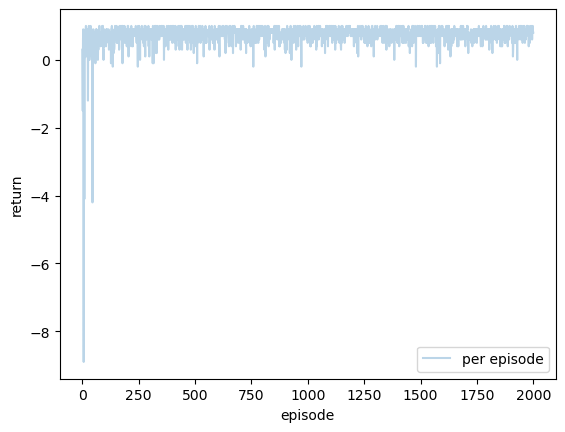

In [22]:
history = train_mc_control(env, policy)
plot_history(history)

100%|██████████| 2000/2000 [00:01<00:00, 1047.81it/s]


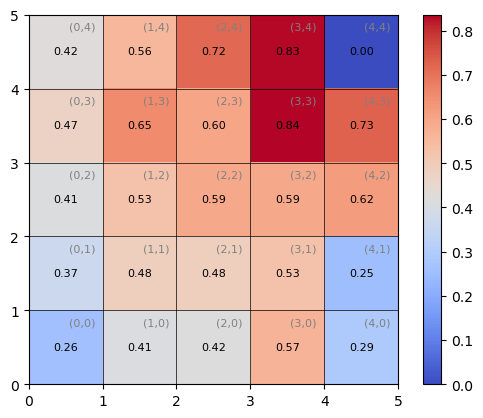

In [23]:
value = ValueFirstVisit()
mc_prediction(env, value, policy)
value.draw()